---

## **Deep Learning Project**
## **Colorectal cancer tissue classification**

---


---

**This notebook is designed to be:**
- **reproducible** (relative paths, fixed seeds)
- **idempotent** (can be re-run without re-downloading if files are already present)
- **traceable** (explicit go/no-go quality gates)

---



---

# PART 6 : Grad-CAM Interpretability

---


---

## Notebook plan - Part 6: Grad-CAM

| Cell | Section | Content |
|------|---------|---------|
| 1-3 | — | Header, principles, title |
| 4 | — | Notebook plan |
| 5 | — | Objective + requirements |
| 6 | — | How Grad-CAM works (algorithm) |
| 7-10 | Config | Imports, versions, seed, constants |
| 11 | Model | Load ResNet fine-tuning from saved file |
| 12 | Grad-CAM | GradCAM class (from scratch, PyTorch hooks) |
| 13 | Grad-CAM | Helper functions (overlay heatmap) |
| 14 | Grad-CAM | Attach Grad-CAM to ResNet-18 (layer4) |
| 15 | Q6.1 | Tumor Epithelium vs Normal Mucosa heatmaps |
| 16 | Q6.1 | Analysis: spatial patterns comparison |
| 17 | Q6.2 | Misclassified image: two heatmaps (predicted vs true) |
| 18 | Q6.2 | Analysis: why the model was confused |
| 19 | Bonus | Grad-CAM for 3 more tissue types (Adipose, Lymphocytes, Smooth Muscle) |
| 20 | Bonus | Context: CNN v1 vs ResNet comparison |
| 21 | Bonus | Grad-CAM on CNN v1 (from scratch) |
| 22 | Bonus | Analysis: CNN vs ResNet attention patterns |
| 23 | — | Total runtime |

---


---

### Objective

Open the "black box" of the best model (ResNet-18 fine-tuning) to understand which regions of the image drive its classification decisions. Grad-CAM (Gradient-weighted Class Activation Mapping) produces heatmaps showing where the model looks when it predicts a given class.

### Project progression
- **Part 2 (MLP)**: 68.02% - pixels treated independently
- **Part 3 (CNN)**: 88.86% / 91.78% (v1) - spatial structure exploited
- **Part 4 (ResNet-18)**: 91.77% fine-tuning - pretrained features adapted
- **Part 5 (ViT)**: 81.98% - global attention, no pretraining
- **Part 6 (Grad-CAM)**: interpret what the best model actually sees

### Requirements
- Implement Grad-CAM from scratch (no external library)
- **Q6.1**: Compare heatmaps for Tumor Epithelium vs Normal Mucosa - describe differences
- **Q6.2**: Show heatmaps for a misclassified image (predicted class vs true class) - explain the confusion

---


---

### How Grad-CAM works

1. **Forward pass**: run the image through the model, capture activations at the last convolutional layer (layer4[1].conv2 for ResNet-18)
2. **Backward pass**: compute gradients of the predicted class score with respect to those activations
3. **Weight the activations**: global average pooling of the gradients gives the importance of each feature map
4. **Generate heatmap**: weighted sum of feature maps, followed by ReLU (keep only positive contributions)
5. **Overlay**: resize the heatmap to the image size and superimpose it

The result shows which pixels contributed most to the model decision. Hot zones = high influence, cold zones = ignored.

---


In [1]:
print("=== Imports ===")
# Imports
# Version 1.0

import sys
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import medmnist
import seaborn as sns
from medmnist import PathMNIST, INFO
from torchvision import transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, f1_score
print("Imports OK")

=== Imports ===
Imports OK


In [2]:
print("=== Versions ===")
# Versions
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"MedMNIST : {medmnist.__version__}")
print(f"NumPy    : {np.__version__}")

=== Versions ===
Python   : 3.12.10
PyTorch  : 2.10.0+cu128
MedMNIST : 3.0.2
NumPy    : 2.4.3


In [3]:
print("=== Reproducibility ===")
# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {DEVICE}")
print(f"cuDNN determ. : {torch.backends.cudnn.deterministic if torch.cuda.is_available() else 'N/A'}")

=== Reproducibility ===
Device        : cuda
cuDNN determ. : True


In [4]:
print("=== Constants and dataset ===")
# Constants and dataset
DATA_DIR = os.path.join(".", "data")
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
N_CLASSES = 9

# Reload dataset
train_dataset = PathMNIST(split='train', download=False, root=DATA_DIR)
val_dataset   = PathMNIST(split='val',   download=False, root=DATA_DIR)
test_dataset  = PathMNIST(split='test',  download=False, root=DATA_DIR)

info = train_dataset.info
labels_names = info['label']
CLASSES = list(labels_names.values())

# Alias DEVICE (Camille utilise DEVICE en majuscule)
DEVICE = DEVICE

# Global timer
notebook_start_time = time.time()

print(f"Device : {DEVICE}")
print(f"Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}")
print("✓ Constants loaded")

os.makedirs(os.path.join(DATA_DIR, 'graphs'), exist_ok=True)
os.makedirs(os.path.join(DATA_DIR, 'models'), exist_ok=True)

=== Constants and dataset ===
Device : cuda
Train : 89996 | Val : 10004 | Test : 7180
✓ Constants loaded


In [5]:
print("=== Load ResNet fine-tuning from saved file ===")
# Load ResNet fine-tuning from saved file
# Allows running this notebook independently from notebook 4
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, N_CLASSES)
model.load_state_dict(torch.load(os.path.join(DATA_DIR, 'models', 'resnet_finetune_model.pth'), map_location=DEVICE))
model = model.to(DEVICE)
model.eval()

# Load test set with ResNet transform
resnet_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
test_rn = PathMNIST(split='test', transform=resnet_transform, download=False, root=DATA_DIR)

print(f"ResNet model loaded from {os.path.join(DATA_DIR, 'models', 'resnet_finetune_model.pth')}")
print(f"Test set : {len(test_rn)} images")
print("✓ Modèle et données prêts pour Grad-CAM")
resnet_full = model  # alias for Camille code

=== Load ResNet fine-tuning from saved file ===
ResNet model loaded from .\data\models\resnet_finetune_model.pth
Test set : 7180 images
✓ Modèle et données prêts pour Grad-CAM


In [6]:
print("=== Grad-CAM ===")
# Grad-CAM
import torch.nn.functional as F
import matplotlib.cm as cm

class GradCAM:
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.activations  = None
        # saved by forward hook, what layer has detected
        self.gradients    = None
        # saved by backward hook, how each activation contributed to prediction
        self._register_hooks()

    def _register_hooks(self):
        # Forward hook: runs AFTER the layer computes its output
        # Saves the activation maps (what the layer detected)
        def forward_hook(module, input, output):
            self.activations = output.detach()
            # get values

        # Backward hook: runs AFTER backprop passes through this layer
        # Saves the gradients (how important each activation was)
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def __call__(self, input_tensor, cls=None):
        self.model.eval()

        # Step 1 Forward pass (also triggers forward_hook)
        # Put the image in the network
        # Hook saves activation of the layer
        logits = self.model(input_tensor)
        if cls is None:
            cls = logits.argmax(dim=1).item()

        # Step 2 Backward pass for the chosen class (triggers backward_hook)
        self.model.zero_grad()
        logits[0, cls].backward()
        # Compute the gradient for the class of interest
        # Not the global loss
        # Meaning : how each parameter contributed to the score

        # Step 3 Global average pooling of gradients, one weight per channel
        # gradients shape: [1, C, h, w]
        # weights shape: [1, C, 1, 1]  (mean over spatial dims h, w)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)

        # Weighted sum of activation maps
        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        # Step 4 ReLU: only keep regions that positively contributed
        # We keep only areas which increased the class scoring
        cam = F.relu(cam)

        # Step 5 Normalisation to [0, 1]
        cam = cam.squeeze()
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        # Avoid division by 0
        return cam.cpu().numpy(), cls

=== Grad-CAM ===


In [7]:
print("=== Helper functions ===")
# Helper functions

def overlay_heatmap(img_tensor, cam, alpha=0.45):
    # Superpose Grad-CAM heatmap onto the original image

    H, W = img_tensor.shape[1], img_tensor.shape[2]

    # Resize image size using bilinear interpolation
    cam_t = torch.tensor(cam).unsqueeze(0).unsqueeze(0)
    cam_r = F.interpolate(cam_t, size=(H, W), mode='bilinear',
                          align_corners=False).squeeze().numpy()

    # Bring image back to displayable [0,1] range
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    # Convert to RGB using jet colormap (blue=low, red=high attention)
    heatmap = cm.jet(cam_r)[:, :, :3]

    # Alpha blend
    blended = (1 - alpha) * img_np + alpha * heatmap
    return np.clip(blended, 0, 1), cam_r


def find_example(dataset, class_idx, model, DEVICE, correct=True):
    # Find a correct and incorrect image
    model.eval()
    for img, label in dataset:
        lbl = int(label.flatten()[0])
        if lbl != class_idx:
            continue
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(DEVICE)).argmax(1).item()
        if correct and pred == lbl:
            return img, lbl, pred
        if not correct and pred != lbl:
            return img, lbl, pred
    return None, None, None


def find_any_wrong(dataset, model, DEVICE):
    # Returns the first misclassified image found in dataset
    # For question 6.2
    model.eval()
    for img, label in dataset:
        lbl = int(label.flatten()[0])
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(DEVICE)).argmax(1).item()
        if pred != lbl:
            return img, lbl, pred
    return None, None, None

=== Helper functions ===


In [8]:
print("=== Attach Grad-CAM to ResNet-18 ===")
# Attach Grad-CAM to ResNet-18
# We hook into layer4[1].conv2 : the very last convolutional layer.
# Early layers detect low-level features (edges, colours)
# Late layers detect high-level semantic features (tissue patterns)
# The last conv layer gives the most interpretable spatial heatmap
# It combines both spatial resolution and semantic meaning

target_layer = resnet_full.layer4[1].conv2
gcam = GradCAM(model=resnet_full, target_layer=target_layer)

print("Grad-CAM ready.")
print("Target layer : resnet_full.layer4[1].conv2")
print("Output shape of this layer : [1, 512, 7, 7] for 224×224 inputs")
print("(7×7 heatmap will be upscaled to 224×224 for overlay)")

=== Attach Grad-CAM to ResNet-18 ===
Grad-CAM ready.
Target layer : resnet_full.layer4[1].conv2
Output shape of this layer : [1, 512, 7, 7] for 224×224 inputs
(7×7 heatmap will be upscaled to 224×224 for overlay)


=== Q6.1 Tumor Epithelium vs Normal Mucosa ===


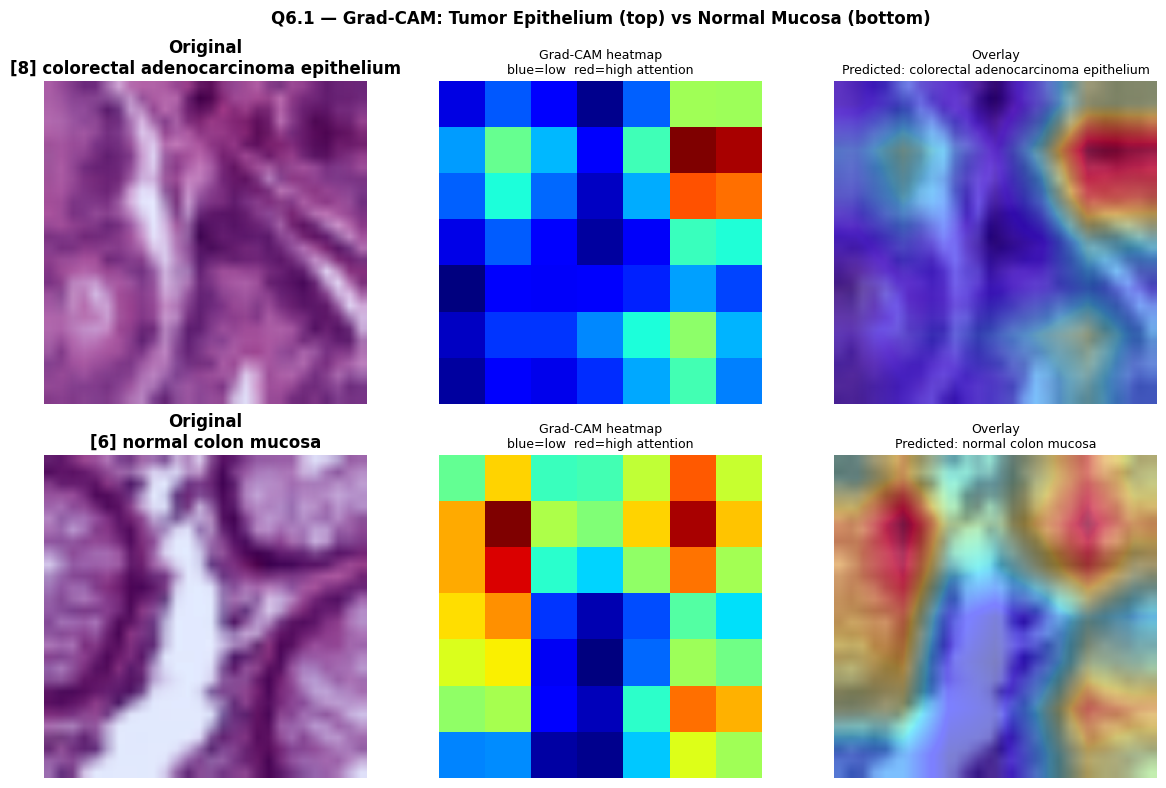

In [9]:
print("=== Q6.1 Tumor Epithelium vs Normal Mucosa ===")
# Q6.1 Tumor Epithelium vs Normal Mucosa
# For a correctly classified Tumor Epithelium image and a correctly classified Normal Mucosa image,
# describe in concrete visual terms what is different about the two Grad-CAM heatmaps.
# Where on the image is the activation concentrated in each case?
# Refer to specific spatial patterns (e.g., “the heatmap highlights the center / edges / clustered regions / scattered spots”)

TUMOR    = 8   # Tumor Epithelium
MUCOSA   = 6   # Normal Mucosa

img_t, lbl_t, pred_t = find_example(test_rn, TUMOR,  resnet_full, DEVICE, correct=True)
img_m, lbl_m, pred_m = find_example(test_rn, MUCOSA, resnet_full, DEVICE, correct=True)

cam_t, _ = gcam(img_t.unsqueeze(0).to(DEVICE), cls=TUMOR)
cam_m, _ = gcam(img_m.unsqueeze(0).to(DEVICE), cls=MUCOSA)

ov_t, _ = overlay_heatmap(img_t, cam_t)
ov_m, _ = overlay_heatmap(img_m, cam_m)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for row, (img, cam, ov, lbl, pred, cls_idx) in enumerate([
        (img_t, cam_t, ov_t, lbl_t, pred_t, TUMOR),
        (img_m, cam_m, ov_m, lbl_m, pred_m, MUCOSA)]):

    # original image
    disp = img.permute(1,2,0).numpy()
    disp = (disp - disp.min()) / (disp.max() - disp.min() + 1e-8)
    axes[row,0].imshow(disp)
    axes[row,0].set_title(f"Original\n[{cls_idx}] {CLASSES[cls_idx]}", fontweight='bold')
    axes[row,0].axis('off')

    # raw heatmap
    axes[row,1].imshow(cam, cmap='jet', vmin=0, vmax=1)
    axes[row,1].set_title("Grad-CAM heatmap\nblue=low  red=high attention", fontsize=9)
    axes[row,1].axis('off')

    # overlay
    axes[row,2].imshow(ov)
    axes[row,2].set_title(f"Overlay\nPredicted: {CLASSES[pred]}", fontsize=9)
    axes[row,2].axis('off')

plt.suptitle("Q6.1 — Grad-CAM: Tumor Epithelium (top) vs Normal Mucosa (bottom)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB6_gradcam_q6_1.png'), dpi=120, bbox_inches='tight')
plt.show()

### Q6.1: Heatmap Differences Between Tumor Epithelium and Normal Mucosa

**Tumor Epithelium**: activation is concentrated in a tight, clustered region (top-right quadrant of the image), corresponding to an area of dense nuclear population. The rest of the image appears cold (blue): the model focuses exclusively on the densely packed cells and ignores the surrounding stroma and empty space.

**Normal Mucosa**: the heatmap is strikingly different. Activation is scattered across multiple distinct spots at the periphery of the tissue, forming a ring-like pattern around the glandular structures. The central lumen (hollow interior of the colonic gland) shows no activation, meaning the model correctly identifies the tissue by its organised glandular architecture rather than the empty space inside.

**Key difference**: Tumor = single dense cluster of activation (chaotic cell proliferation). Mucosa = scattered peripheral spots (organised glandular structure). The model distinguishes the two by the spatial distribution of activation: concentrated vs dispersed.

---


=== Q6.2: Misclassified image: heatmap for both classe ===
Misclassified image found:
  True class      : 5  (smooth muscle)
  Predicted class : 2  (debris)


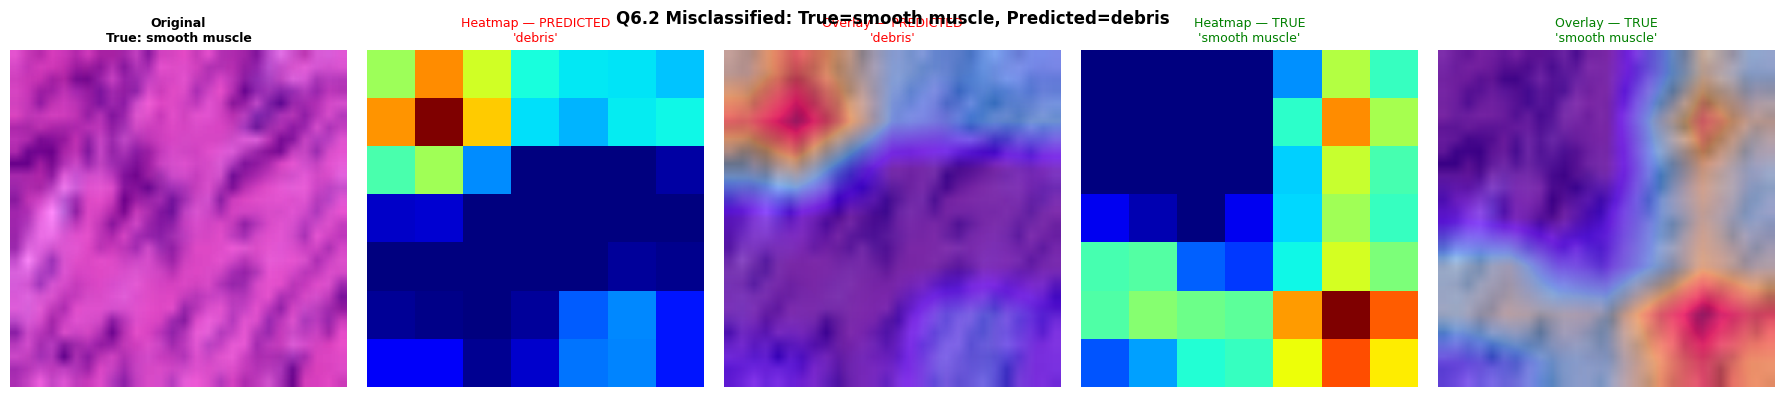

In [10]:
print("=== Q6.2: Misclassified image: heatmap for both classe ===")
# Q6.2: Misclassified image: heatmap for both classes
# Pick one of your misclassified images. Apply Grad-CAM for both the predicted class and the true class.
# Show both heatmaps side by side. What does the comparison tell you about why the model was confused?

img_w, true_cls, pred_cls = find_any_wrong(test_rn, resnet_full, DEVICE)

print(f"Misclassified image found:")
print(f"  True class      : {true_cls}  ({CLASSES[true_cls]})")
print(f"  Predicted class : {pred_cls}  ({CLASSES[pred_cls]})")

# Heatmap explaining WHY the model chose the wrong class
cam_pred, _ = gcam(img_w.unsqueeze(0).to(DEVICE), cls=pred_cls)
# Heatmap showing what would have led to the correct class
cam_true, _ = gcam(img_w.unsqueeze(0).to(DEVICE), cls=true_cls)

ov_pred, _ = overlay_heatmap(img_w, cam_pred)
ov_true, _ = overlay_heatmap(img_w, cam_true)

disp = img_w.permute(1,2,0).numpy()
disp = (disp - disp.min()) / (disp.max() - disp.min() + 1e-8)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

axes[0].imshow(disp)
axes[0].set_title(f"Original\nTrue: {CLASSES[true_cls]}", fontweight='bold', fontsize=9)
axes[0].axis('off')

axes[1].imshow(cam_pred, cmap='jet', vmin=0, vmax=1)
axes[1].set_title(f"Heatmap — PREDICTED\n'{CLASSES[pred_cls]}'", fontsize=9, color='red')
axes[1].axis('off')

axes[2].imshow(ov_pred)
axes[2].set_title(f"Overlay — PREDICTED\n'{CLASSES[pred_cls]}'", fontsize=9, color='red')
axes[2].axis('off')

axes[3].imshow(cam_true, cmap='jet', vmin=0, vmax=1)
axes[3].set_title(f"Heatmap — TRUE\n'{CLASSES[true_cls]}'", fontsize=9, color='green')
axes[3].axis('off')

axes[4].imshow(ov_true)
axes[4].set_title(f"Overlay — TRUE\n'{CLASSES[true_cls]}'", fontsize=9, color='green')
axes[4].axis('off')

plt.suptitle(f"Q6.2 Misclassified: True={CLASSES[true_cls]}, Predicted={CLASSES[pred_cls]}",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB6_gradcam_q6_2.png'), dpi=120, bbox_inches='tight')
plt.show()

### Q6.2: What the two heatmaps reveal about the confusion
The explanation is biological :
Tumoral tissue is very ofter infiltrated by immune cells such as lymphocytes. These immune cells can fight or help the spread of the tumor depending on different biological parameters. In the picture, accumulation of lymphocytes cells or cancer cells have a very similar profile.
The model focus on the infiltrate instead of the tumor area.


=== Grad-CAM for 3 more tissue types ===


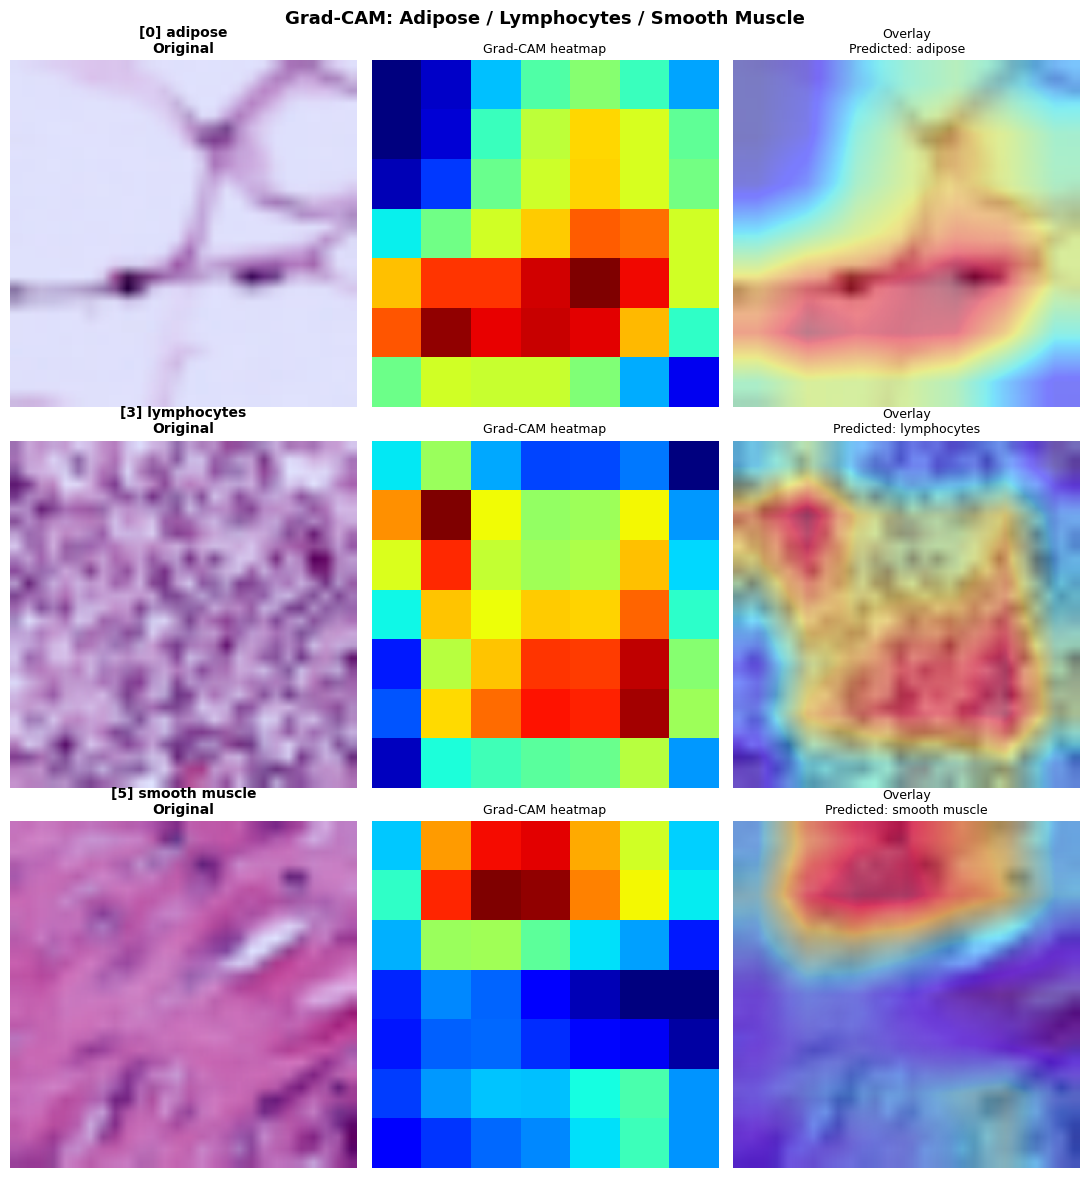

In [11]:
print("=== Grad-CAM for 3 more tissue types ===")
# Grad-CAM for 3 more tissue types
SHOWCASE = [0, 3, 5]
# Adipose, Lymphocytes, Smooth Muscle

fig, axes = plt.subplots(len(SHOWCASE), 3, figsize=(11, 4 * len(SHOWCASE)))

for row, cls_idx in enumerate(SHOWCASE):
    img_s, lbl_s, pred_s = find_example(test_rn, cls_idx, resnet_full, DEVICE, correct=True)
    cam_s, _ = gcam(img_s.unsqueeze(0).to(DEVICE), cls=cls_idx)
    ov_s, _  = overlay_heatmap(img_s, cam_s)

    disp = img_s.permute(1,2,0).numpy()
    disp = (disp - disp.min()) / (disp.max() - disp.min() + 1e-8)

    axes[row,0].imshow(disp)
    axes[row,0].set_title(f"[{cls_idx}] {CLASSES[cls_idx]}\nOriginal",
                          fontweight='bold', fontsize=10)
    axes[row,0].axis('off')

    axes[row,1].imshow(cam_s, cmap='jet', vmin=0, vmax=1)
    axes[row,1].set_title("Grad-CAM heatmap", fontsize=9)
    axes[row,1].axis('off')

    axes[row,2].imshow(ov_s)
    axes[row,2].set_title(f"Overlay\nPredicted: {CLASSES[pred_s]}", fontsize=9)
    axes[row,2].axis('off')

plt.suptitle("Grad-CAM: Adipose / Lymphocytes / Smooth Muscle",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'graphs', 'NB6_gradcam_extra.png'), dpi=120, bbox_inches='tight')
plt.show()

---

### BONUS: Applying Grad-CAM to the CNN (Part 3)

The Grad-CAM analysis above was performed on the ResNet-18 fine-tuning (91.77% test accuracy, 11.1M parameters, pretrained on ImageNet). A natural question arises: does our CNN v1 from scratch (91.78% test accuracy, 436K parameters, no pretraining) focus on the same tissue regions?

This is a unique opportunity to compare two models that:
- Achieve the **same accuracy** (91.77% vs 91.78%)
- Have **completely different origins** (ImageNet features vs learned from scratch)
- Use **different architectures** (residual blocks vs plain convolutions)
- Have **25x different parameter counts** (11.1M vs 436K)

If both models highlight the same regions, it validates that those regions are the true biological markers. If they differ, it reveals complementary visual strategies.

---


=== BONUS - Grad-CAM on CNN (best model v1) ===
CNN v1 loaded


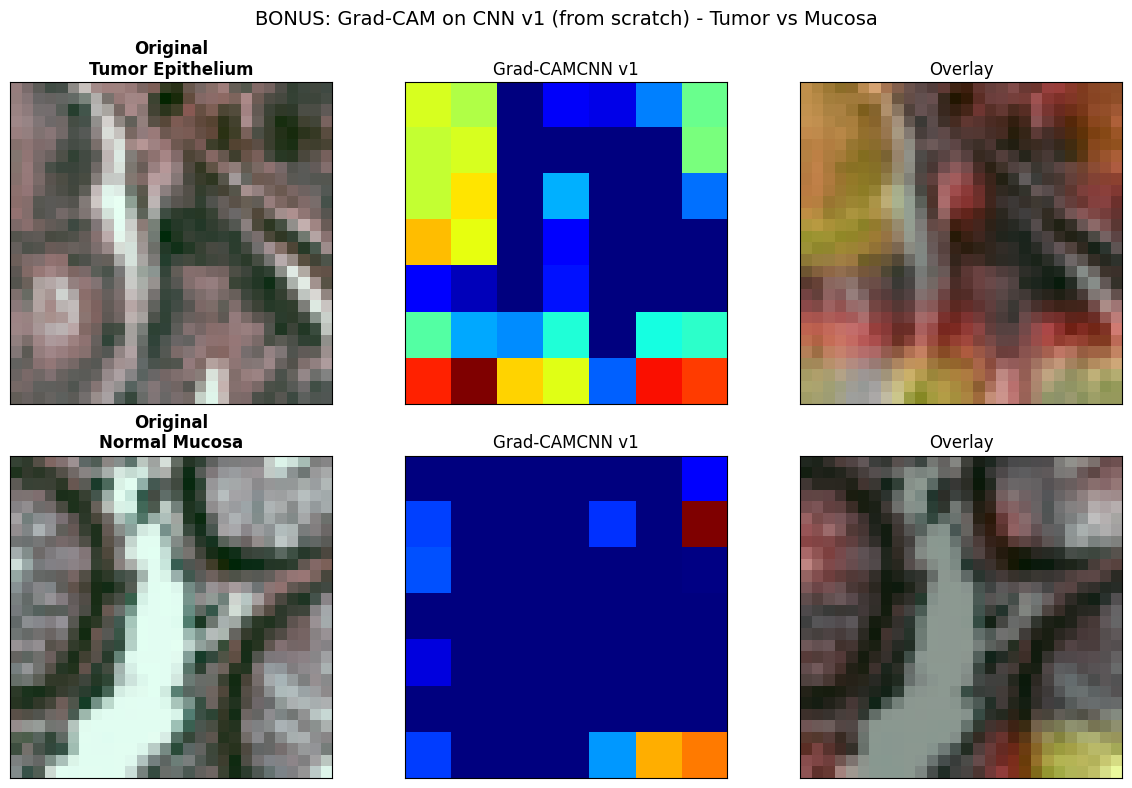

In [ ]:
print("=== BONUS - Grad-CAM on CNN (best model v1) ===")
# Load CNN v1 model
import torch.nn as nn

def create_cnn(n_classes=9):
    model = nn.Sequential(
        nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.25),
        nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.35),
        nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
        nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
        nn.MaxPool2d(2, 2), nn.Dropout(0.5),
        nn.Flatten(),
        nn.Linear(128 * 3 * 3, 128), nn.ReLU(), nn.Dropout(0.5),
        nn.Linear(128, n_classes)
    )
    return model

cnn_model = create_cnn()
cnn_model.load_state_dict(torch.load(os.path.join(DATA_DIR, "models", "NB3_cnn_model_v1.pth"), map_location=DEVICE))
cnn_model = cnn_model.to(DEVICE)
cnn_model.eval()
print("CNN v1 loaded")

# Grad-CAM on CNN - hook on last conv layer (layer index 17 = Conv2d 128->128)
cnn_gradcam = GradCAM(cnn_model, target_layer=cnn_model[17])

# Same test images as ResNet for comparison
TUMOR = 8
MUCOSA = 6

# Load test set with CNN transform (no resize)
cnn_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.7405, 0.5330, 0.7058], [0.1237, 0.1768, 0.1244])
])
test_cnn = PathMNIST(split="test", transform=cnn_transform, download=False, root=DATA_DIR)

img_t, lbl_t, pred_t = find_example(test_cnn, TUMOR, cnn_model, DEVICE, correct=True)
img_m, lbl_m, pred_m = find_example(test_cnn, MUCOSA, cnn_model, DEVICE, correct=True)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for row, (img, lbl, cls_idx, cls_name) in enumerate([
    (img_t, lbl_t, TUMOR, "Tumor Epithelium"),
    (img_m, lbl_m, MUCOSA, "Normal Mucosa")
]):
    cam, _ = cnn_gradcam(img.unsqueeze(0).to(DEVICE), cls=cls_idx)
    disp = img.permute(1,2,0).cpu().numpy()
    disp = (disp - disp.min()) / (disp.max() - disp.min())
    import matplotlib.cm as cm_cmap
    from PIL import Image
    cam_resized = np.array(Image.fromarray((cm_cmap.hot(cam / (cam.max() + 1e-8))[:,:,:3] * 255).astype(np.uint8)).resize((28, 28))) / 255.0
    ov = disp * 0.6 + cam_resized * 0.4
    axes[row,0].imshow(disp)
    axes[row,0].set_title(f"Original\n{cls_name}", fontweight="bold")
    axes[row,1].imshow(cam, cmap="jet", vmin=0, vmax=1)
    axes[row,1].set_title(f"Grad-CAMCNN v1")
    axes[row,2].imshow(ov)
    axes[row,2].set_title(f"Overlay")
    for ax in axes[row]: ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("BONUS: Grad-CAM on CNN v1 (from scratch) - Tumor vs Mucosa", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "graphs", "NB6_gradcam_cnn_v1.png"), dpi=120, bbox_inches="tight")
plt.show()


---

### BONUS: CNN v1 vs ResNet-18 — what each model looks at

Both models achieve nearly identical test accuracy (CNN v1: 91.78%, ResNet fine-tuning: 91.77%), yet the Grad-CAM heatmaps reveal different visual strategies:

**ResNet-18 (pretrained + fine-tuned):**
- Tumor: activation concentrated on the right side, targeting the dense violet nuclear clusters
- Mucosa: activation dispersed across multiple peripheral zones, with the central glandular lumen ignored
- The ResNet uses broad, distributed attention patterns, likely leveraging its ImageNet-learned texture detectors

**CNN v1 (from scratch):**
- Tumor: activation in the upper-left quadrant, focused on the darkest, densest tissue regions. More diffuse than ResNet
- Mucosa: very sparse activation, concentrated in the bottom-right corner only. The CNN is more selective than the ResNet

**Key insight:** the two architectures focus on different sub-regions of the same tissue type, yet reach the same accuracy. This suggests that multiple visual strategies can lead to correct classification in histology. The ResNet uses broader contextual features (inherited from ImageNet), while the CNN relies on more localised, high-contrast patterns learned from scratch. An ensemble of both models could potentially outperform either one alone by combining complementary attention patterns.

---


In [13]:
print("=== Total notebook runtime ===")
# Total notebook runtime
notebook_total_time = time.time() - notebook_start_time
print(f"Total notebook runtime : {notebook_total_time:.1f}s ({notebook_total_time/60:.1f} min)")

=== Total notebook runtime ===
Total notebook runtime : 2.7s (0.0 min)
